In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.1 * size)
train_size = int(size-test_size -valid_size)

trainset, validset,testset = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.37787493422372,train_accu=0.8726285714285714
Epoch=0,valid_loss=0.4570810043811798,valid_accu=0.8431
0
Epoch=1,train_loss=0.29925844569546833,train_accu=0.8994571428571428
Epoch=1,valid_loss=0.42672940752506255,valid_accu=0.8483
0
Epoch=2,train_loss=0.2572668376999242,train_accu=0.9151142857142858
Epoch=2,valid_loss=0.42251836009025573,valid_accu=0.8544
0
Epoch=3,train_loss=0.2027407588141305,train_accu=0.9342857142857143
Epoch=3,valid_loss=0.41192155361175536,valid_accu=0.8561
0
Epoch=4,train_loss=0.1634483821937016,train_accu=0.9525142857142858
Epoch=4,valid_loss=0.39220990619659424,valid_accu=0.8637
0
Epoch=5,train_loss=0.11821382011515753,train_accu=0.9664857142857143
Epoch=5,valid_loss=0.3676249888420105,valid_accu=0.8736
0
Epoch=6,train_loss=0.10843883043868201,train_accu=0.9677714285714286
Epoch=6,valid_loss=0.3918873740673065,valid_accu=0.8688
Epoch=7,train_loss=0.09039017621874809,train_accu=0.9755428571428572
Epoch=7,valid_loss=0.39642622903585434,valid_a

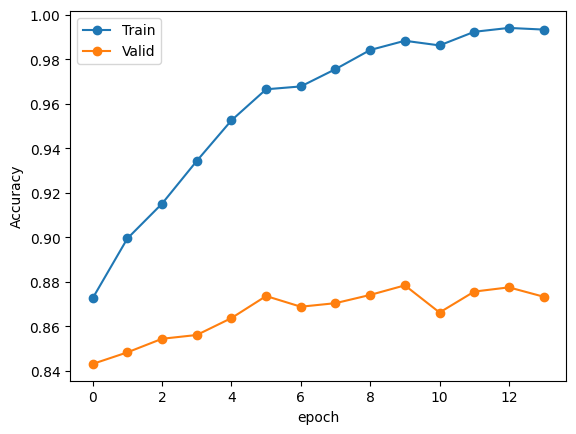

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.0498929612168244, 0.9878285714285714)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.3948538629591465, 0.8746)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=2*p*r/(p+r)
each_accu

airplane      0.988063
automobile    0.994816
bird          0.984127
cat           0.980049
deer          0.981233
dog           0.982230
frog          0.994187
horse         0.990392
ship          0.990378
truck         0.992722
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(4).index.map(trainset.dataset.classess)]
targetF

[3, 4, 5, 2]

In [17]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(13948, 21052)

In [18]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(4046, 5954)

In [19]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [20]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [53]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,model_0=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    # elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
    #     model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    torch.cuda.empty_cache() 
    return model

Epoch=0,train_loss=0.04427224629830037,train_accu=0.9842857142857143
Epoch=0,valid_loss=0.15980413498356938,valid_accu=0.9406
0
Epoch=1,train_loss=0.028903389579589878,train_accu=0.9920571428571429
Epoch=1,valid_loss=0.15313192724511027,valid_accu=0.9433
0
Epoch=2,train_loss=0.02648457583896816,train_accu=0.9940285714285715
Epoch=2,valid_loss=0.1537614070519805,valid_accu=0.9444
0
Epoch=3,train_loss=0.013929670221957246,train_accu=0.9966857142857143
Epoch=3,valid_loss=0.15559940894600005,valid_accu=0.9476
0
Epoch=4,train_loss=0.010190806790815467,train_accu=0.9975714285714286
Epoch=4,valid_loss=0.165648523292318,valid_accu=0.9493
0
Epoch=5,train_loss=0.017890812997386926,train_accu=0.9958285714285714
Epoch=5,valid_loss=0.17859633711501957,valid_accu=0.944
Epoch=6,train_loss=0.007528677327145955,train_accu=0.9987142857142857
Epoch=6,valid_loss=0.1908122583533637,valid_accu=0.9459
Epoch=7,train_loss=0.004327830980713978,train_accu=0.9995428571428572
Epoch=7,valid_loss=0.17074446129985155

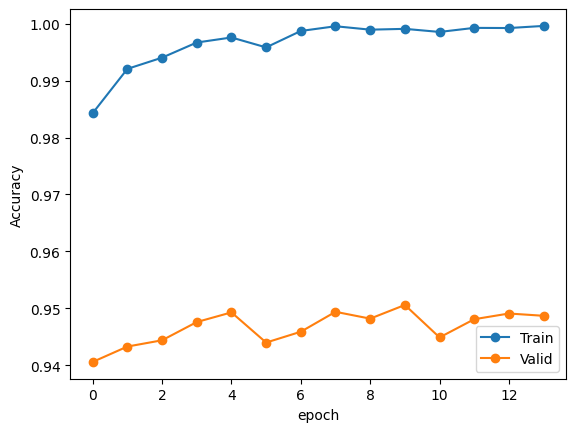

In [22]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,model_0=model_0)

In [23]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.03201286196984732,train_accu=0.9916397491924758
Epoch=0,valid_loss=0.17010863719468633,valid_accu=0.9442391669465905
0
Epoch=1,train_loss=0.036906337714289535,train_accu=0.9874596237887137
Epoch=1,valid_loss=0.21521389146409056,valid_accu=0.9324823647967753
Epoch=2,train_loss=0.016951277628556697,train_accu=0.9951073532205966
Epoch=2,valid_loss=0.1906008600461621,valid_accu=0.9425596237823312
Epoch=3,train_loss=0.02223847232437469,train_accu=0.9938723161694851
Epoch=3,valid_loss=0.20978612180450118,valid_accu=0.9388646288209607
Epoch=4,train_loss=0.014390921311470857,train_accu=0.9965798973969219
Epoch=4,valid_loss=0.2077264008918204,valid_accu=0.9383607658716829
4 Early stopping!


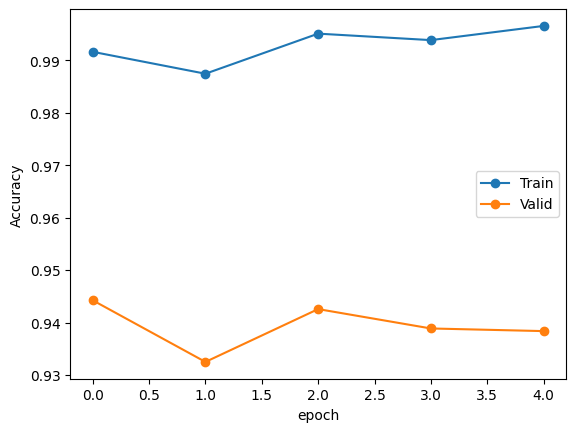

In [24]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.14799305797050566,train_accu=0.9521795239460855
Epoch=0,valid_loss=0.3677857557824503,valid_accu=0.865546218487395
0
Epoch=1,train_loss=0.1185948413996769,train_accu=0.967307140808718
Epoch=1,valid_loss=0.3382477273725367,valid_accu=0.8727137913989125
0
Epoch=2,train_loss=0.0759561897683082,train_accu=0.9779179810725552
Epoch=2,valid_loss=0.333569758034436,valid_accu=0.8781512605042017
0
Epoch=3,train_loss=0.052167704546301145,train_accu=0.9865930599369085
Epoch=3,valid_loss=0.34625754852696805,valid_accu=0.8877904102817598
0
Epoch=4,train_loss=0.06318547629548549,train_accu=0.9801405219386292
Epoch=4,valid_loss=0.36217721627893507,valid_accu=0.8818586258032625
Epoch=5,train_loss=0.07047356441638379,train_accu=0.9747634069400631
Epoch=5,valid_loss=0.39723986533097094,valid_accu=0.8791398912506179
Epoch=6,train_loss=0.02953100697745566,train_accu=0.9928305133352452
Epoch=6,valid_loss=0.3262299688222661,valid_accu=0.8959466139396935
0
Epoch=7,train_loss=0.02785330463

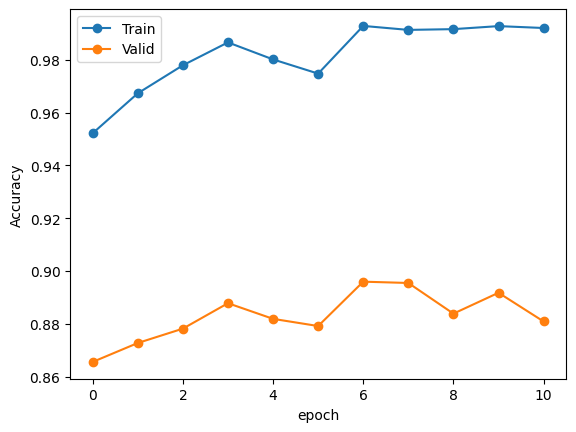

In [54]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [26]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.005049190144483665, 0.9992571428571428)

In [27]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.17874374443627894, 0.9506)

In [28]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.03252813817341105, 0.9912597377921337)

In [55]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.031019073605466903, 0.9916833954688844)

In [30]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.17728088869468295, 0.9415518978837756)

In [56]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.33098665738291394, 0.8952051408798813)

In [57]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d

(0.031335379182121585, 0.9918857142857143)

In [58]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.23554501621127127, 0.9234, 4046)

In [59]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.13415530127984074, 0.9820285714285715, 14012, 20988)

In [60]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.8010753182590008, 0.8825, 4138, 5862)

In [61]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [62]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'splitmode={split_mode}')
df

splitmode=('classaccu', [3, 4, 5, 2])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.049893,0.987829,0.394854,0.874600
1,Model_Decision,0.005049,0.999257,0.178744,0.950600
2,Model_T,0.032528,0.991260,0.177281,0.941552
3,Model_F,0.031019,0.991683,0.330987,0.895205
4,Total_Model,0.134155,0.982029,0.801075,0.882500
5,Total_Model_without_decision,0.031335,0.991886,0.235545,0.923400


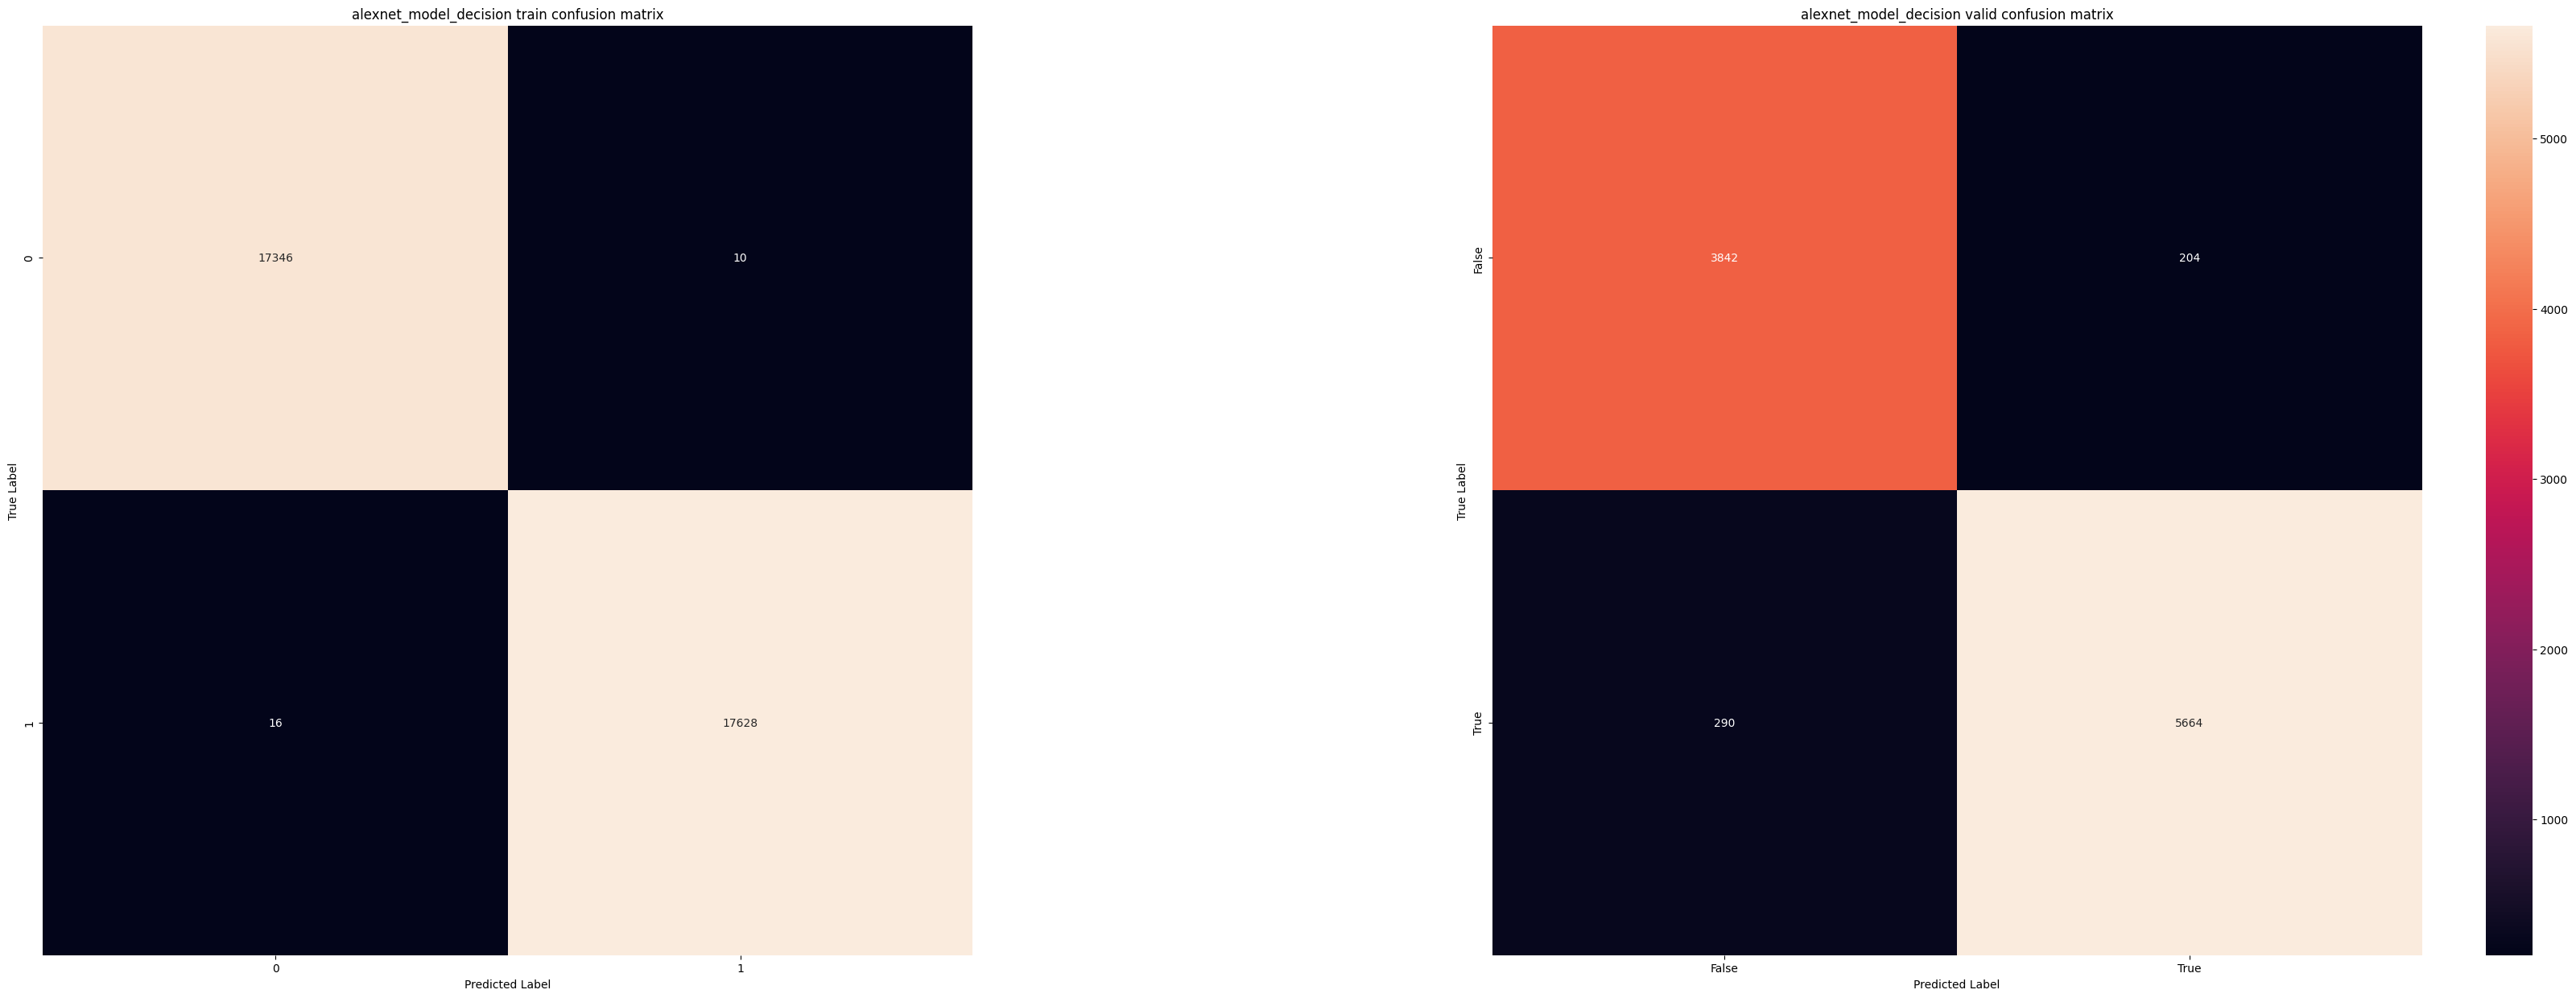

In [38]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

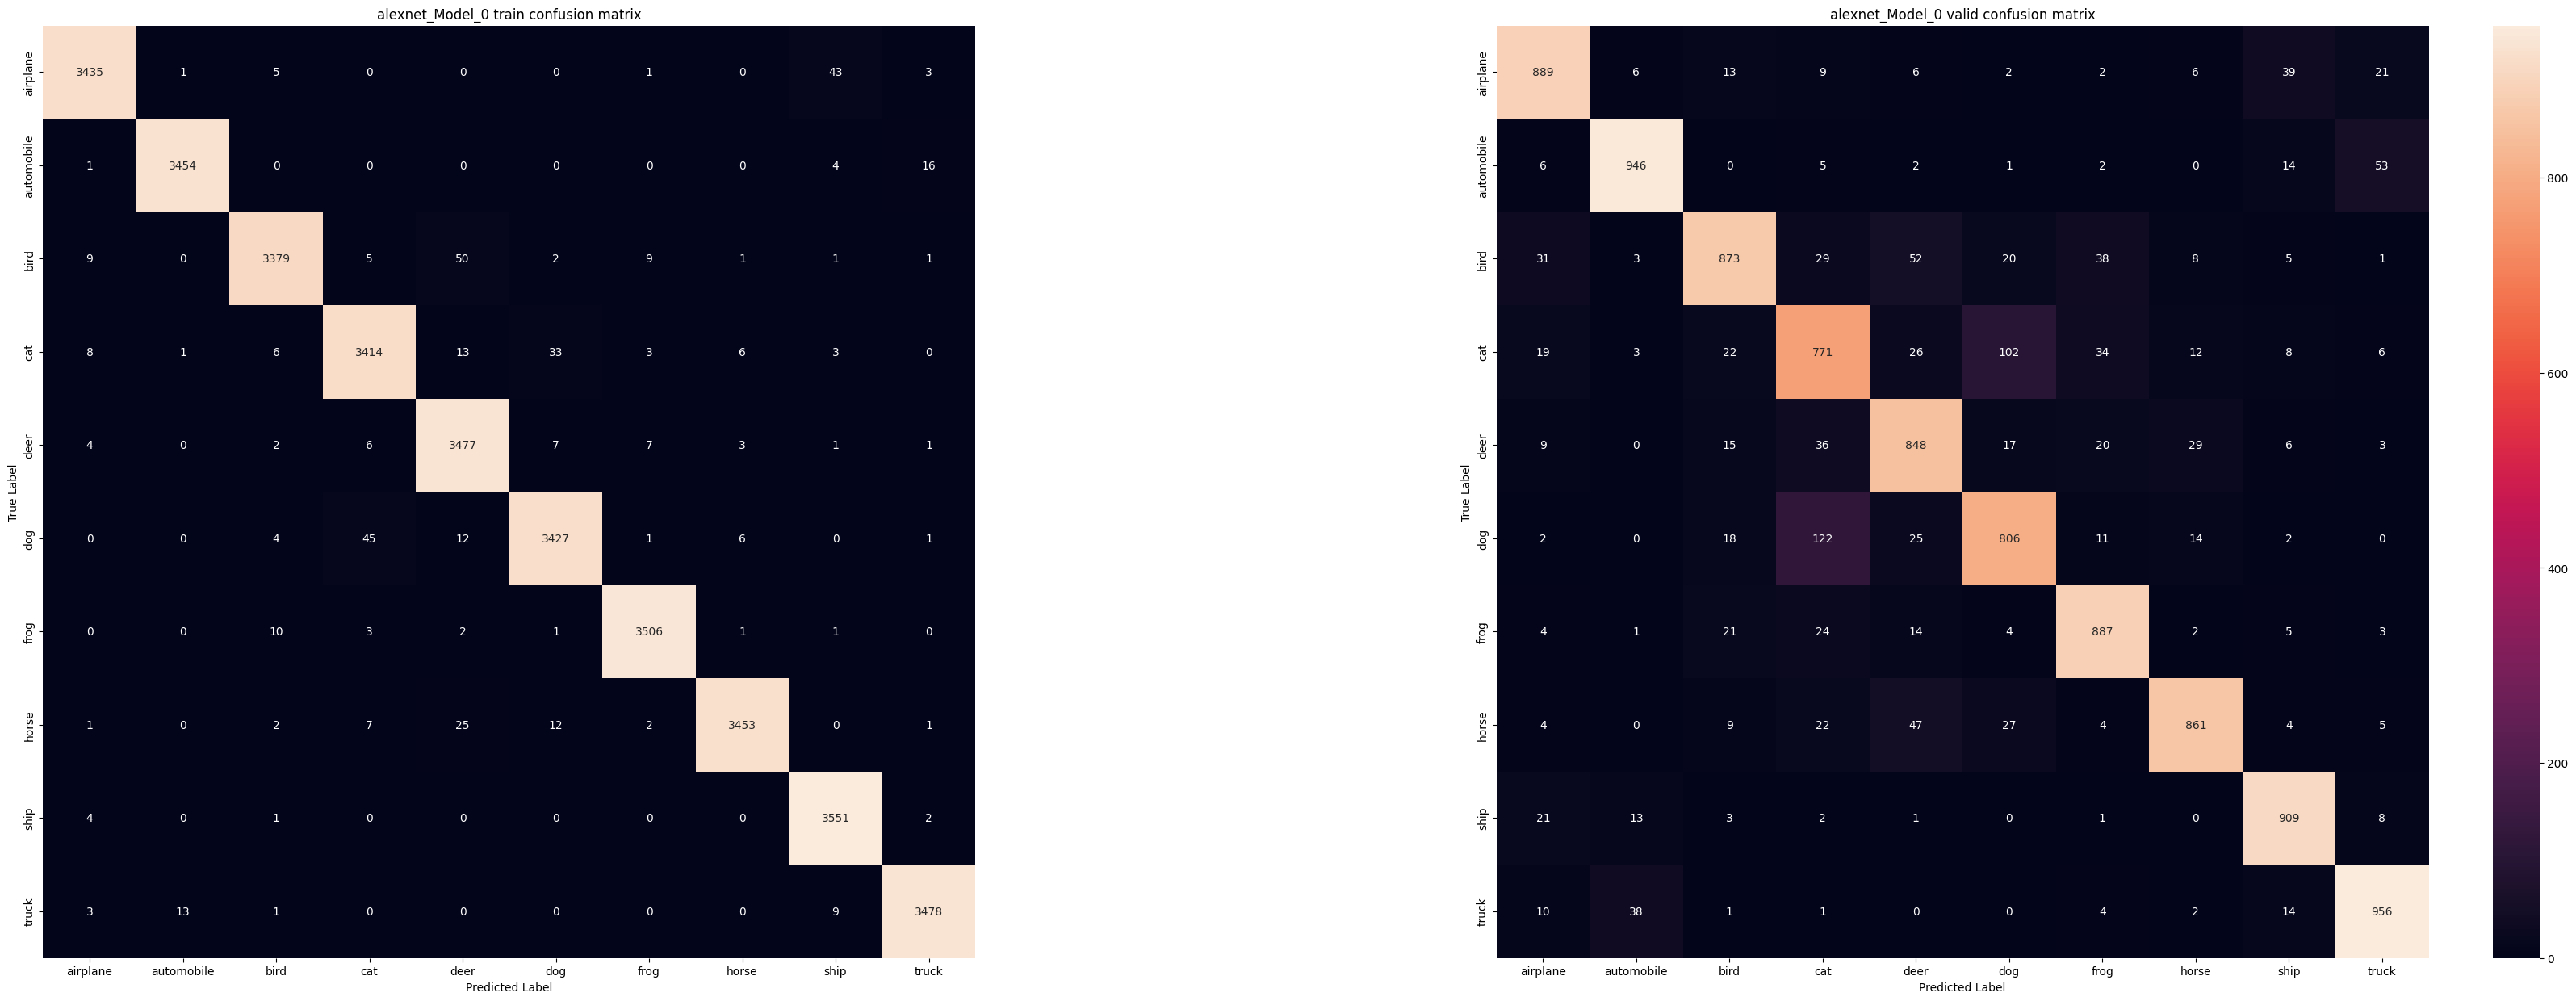

In [39]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

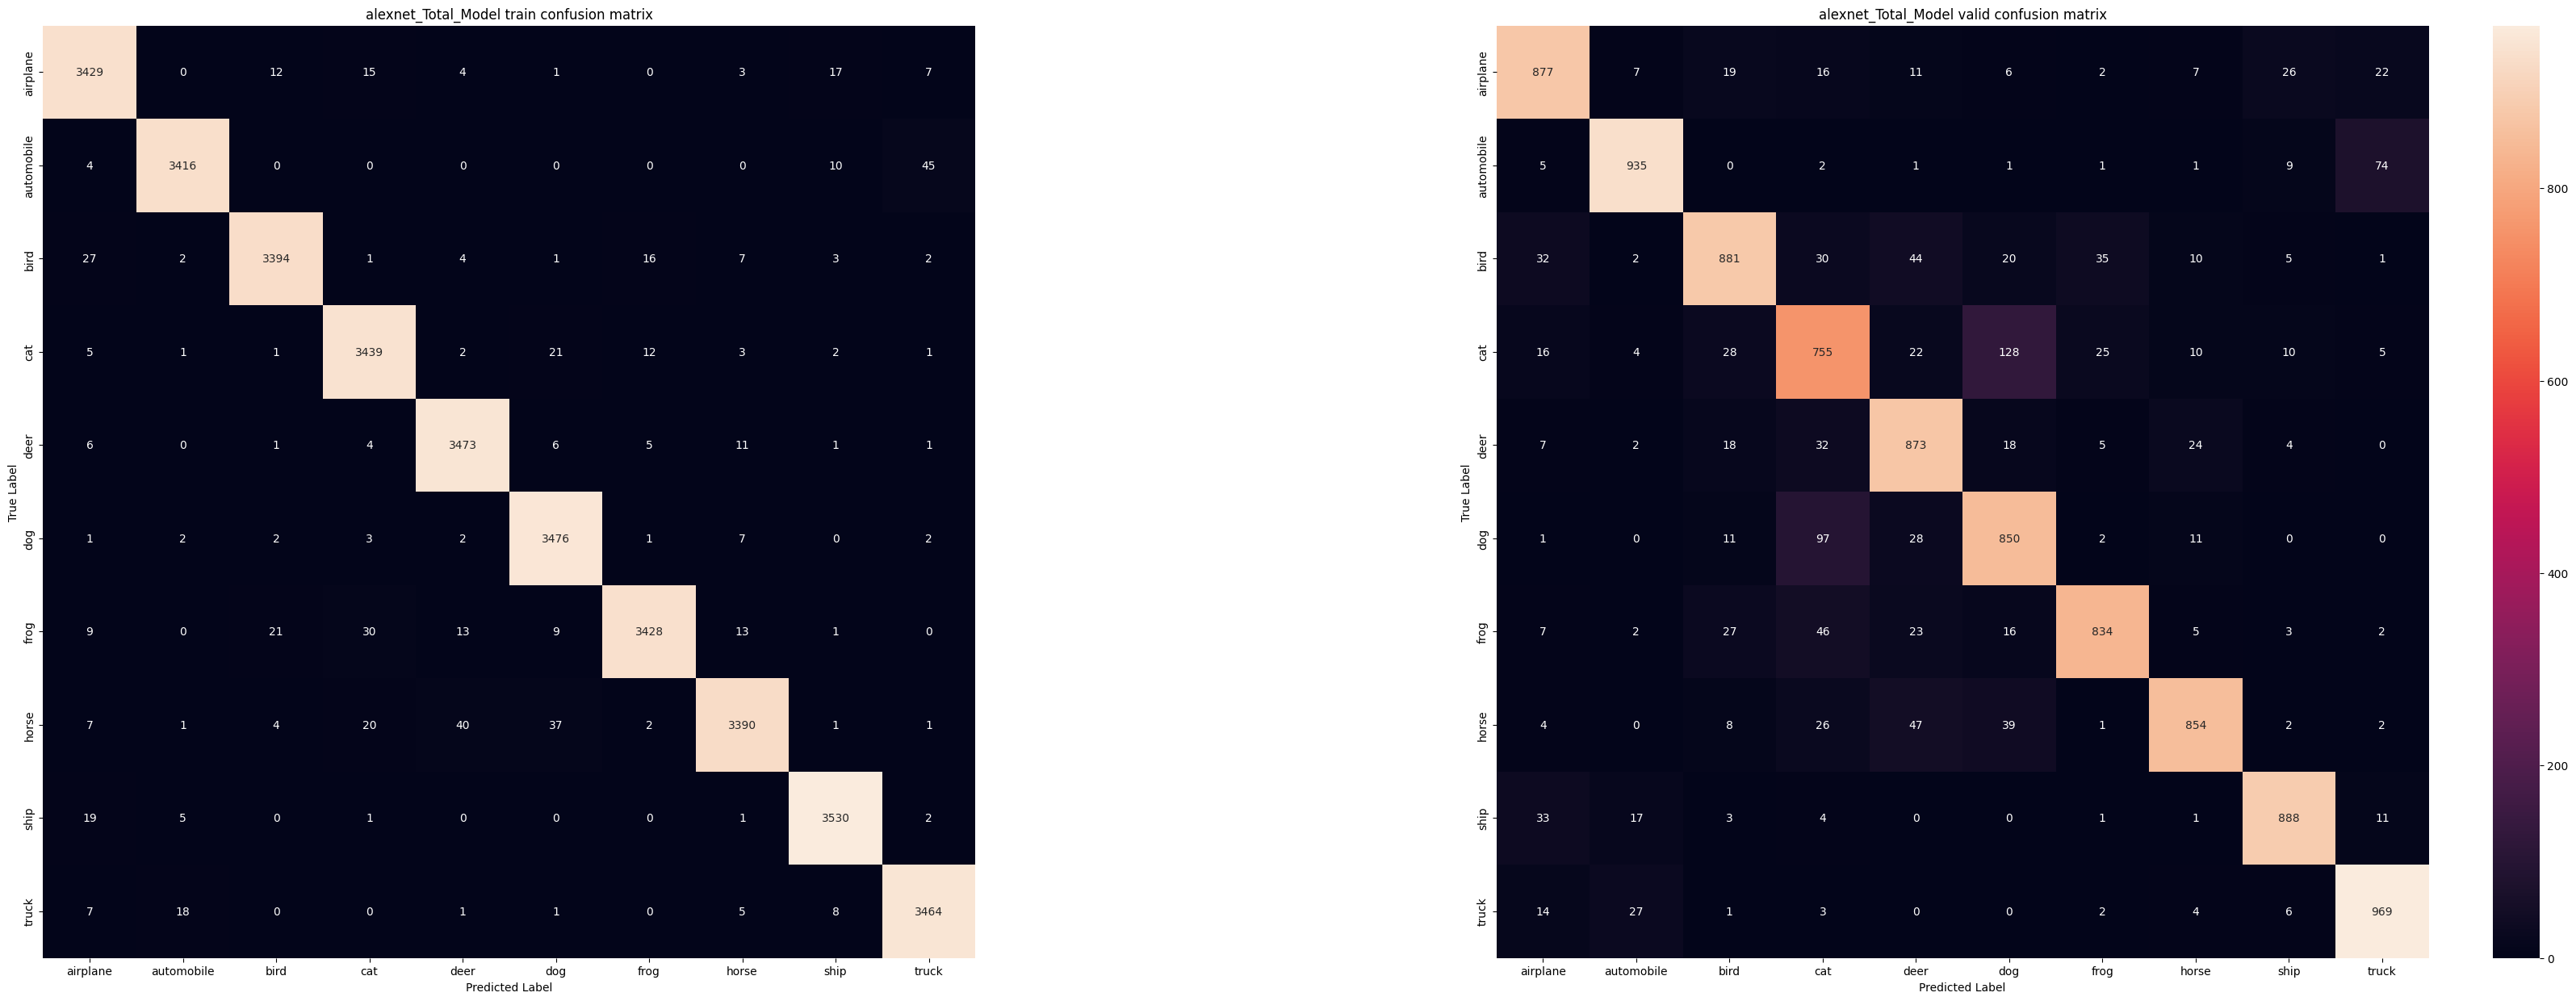

In [40]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

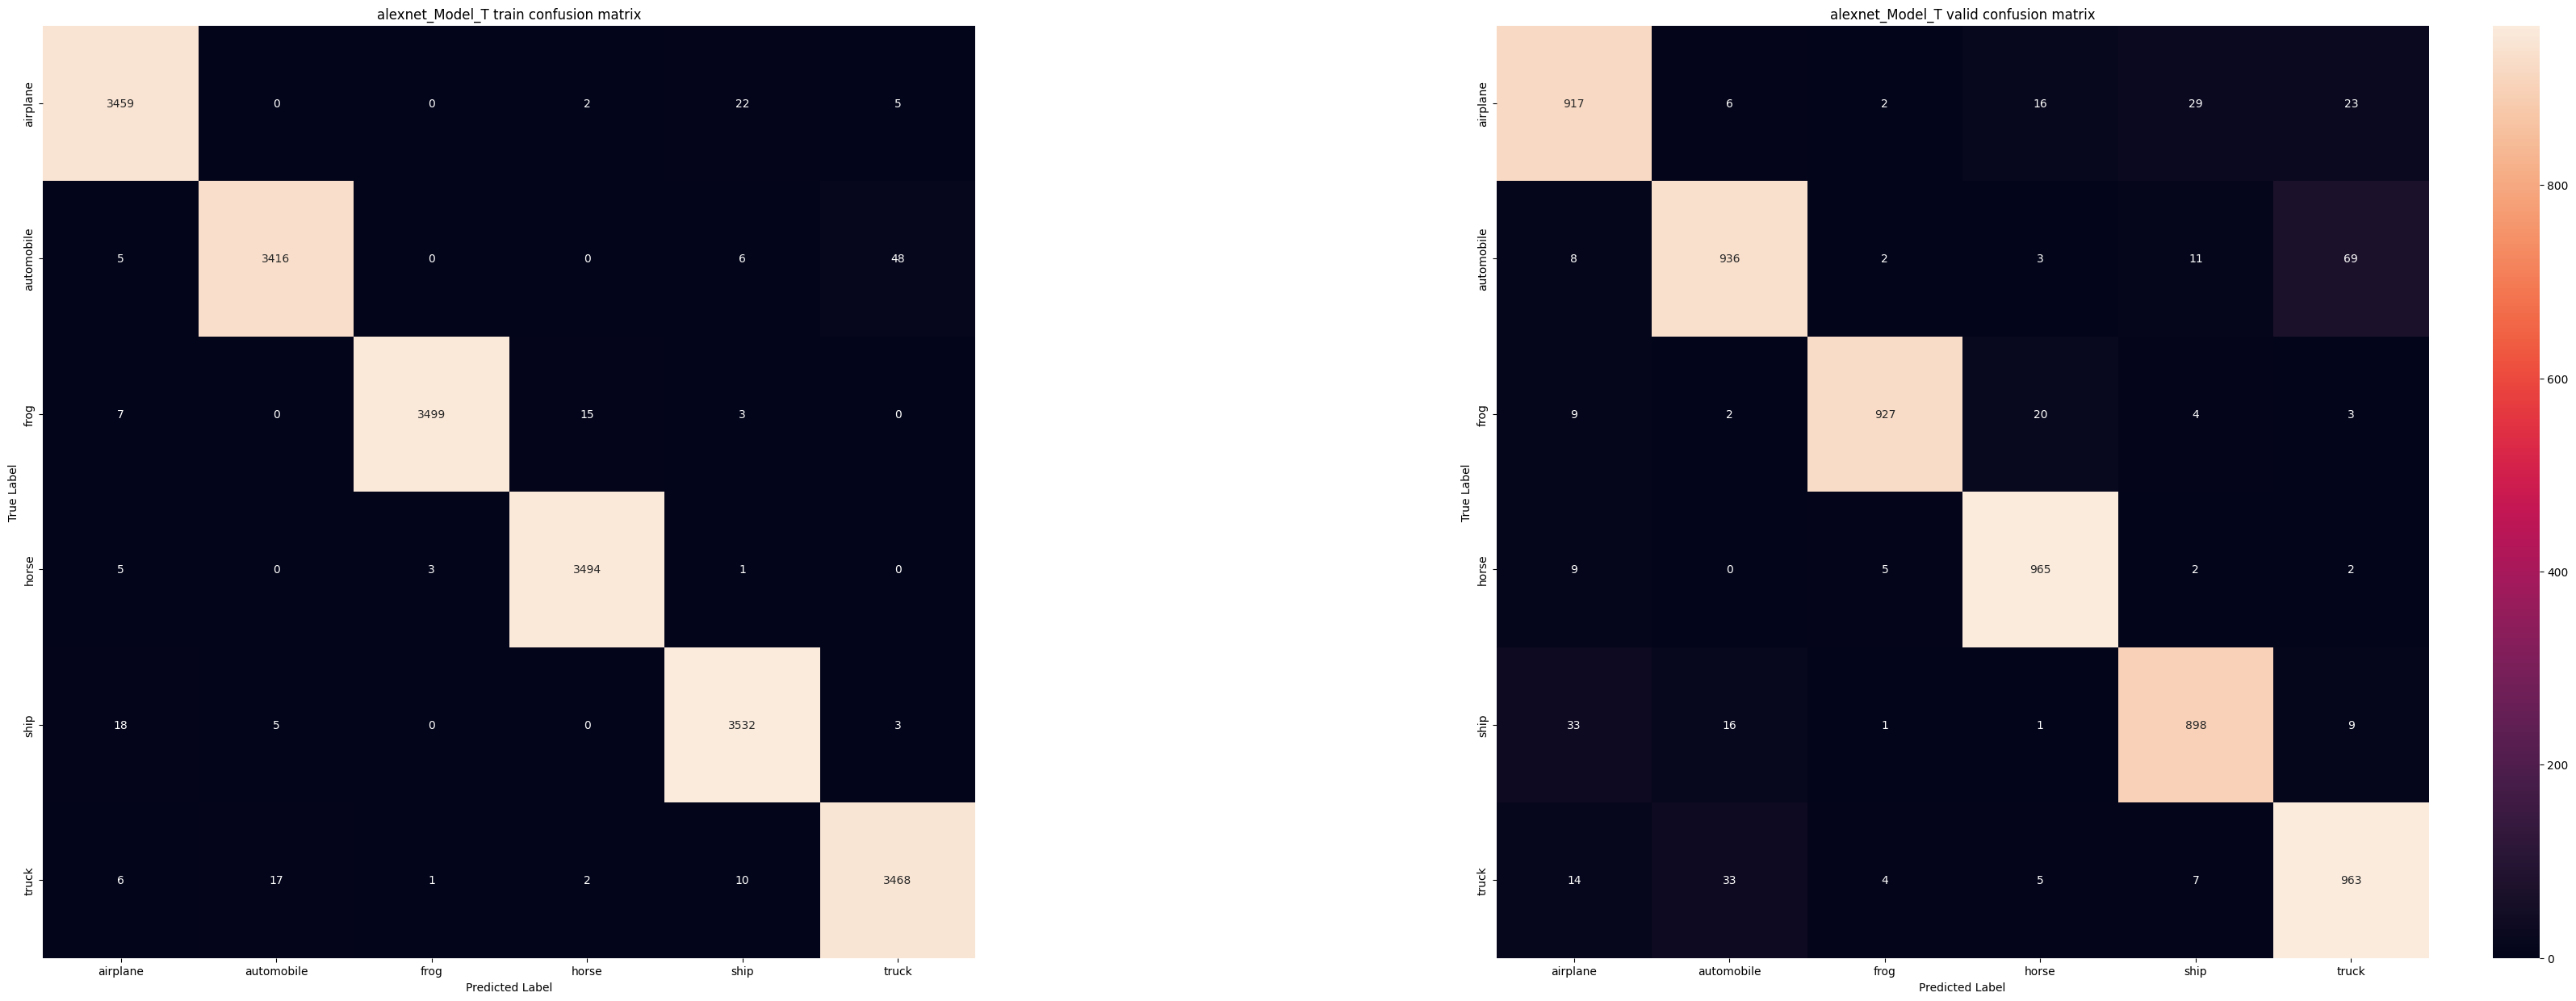

In [41]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

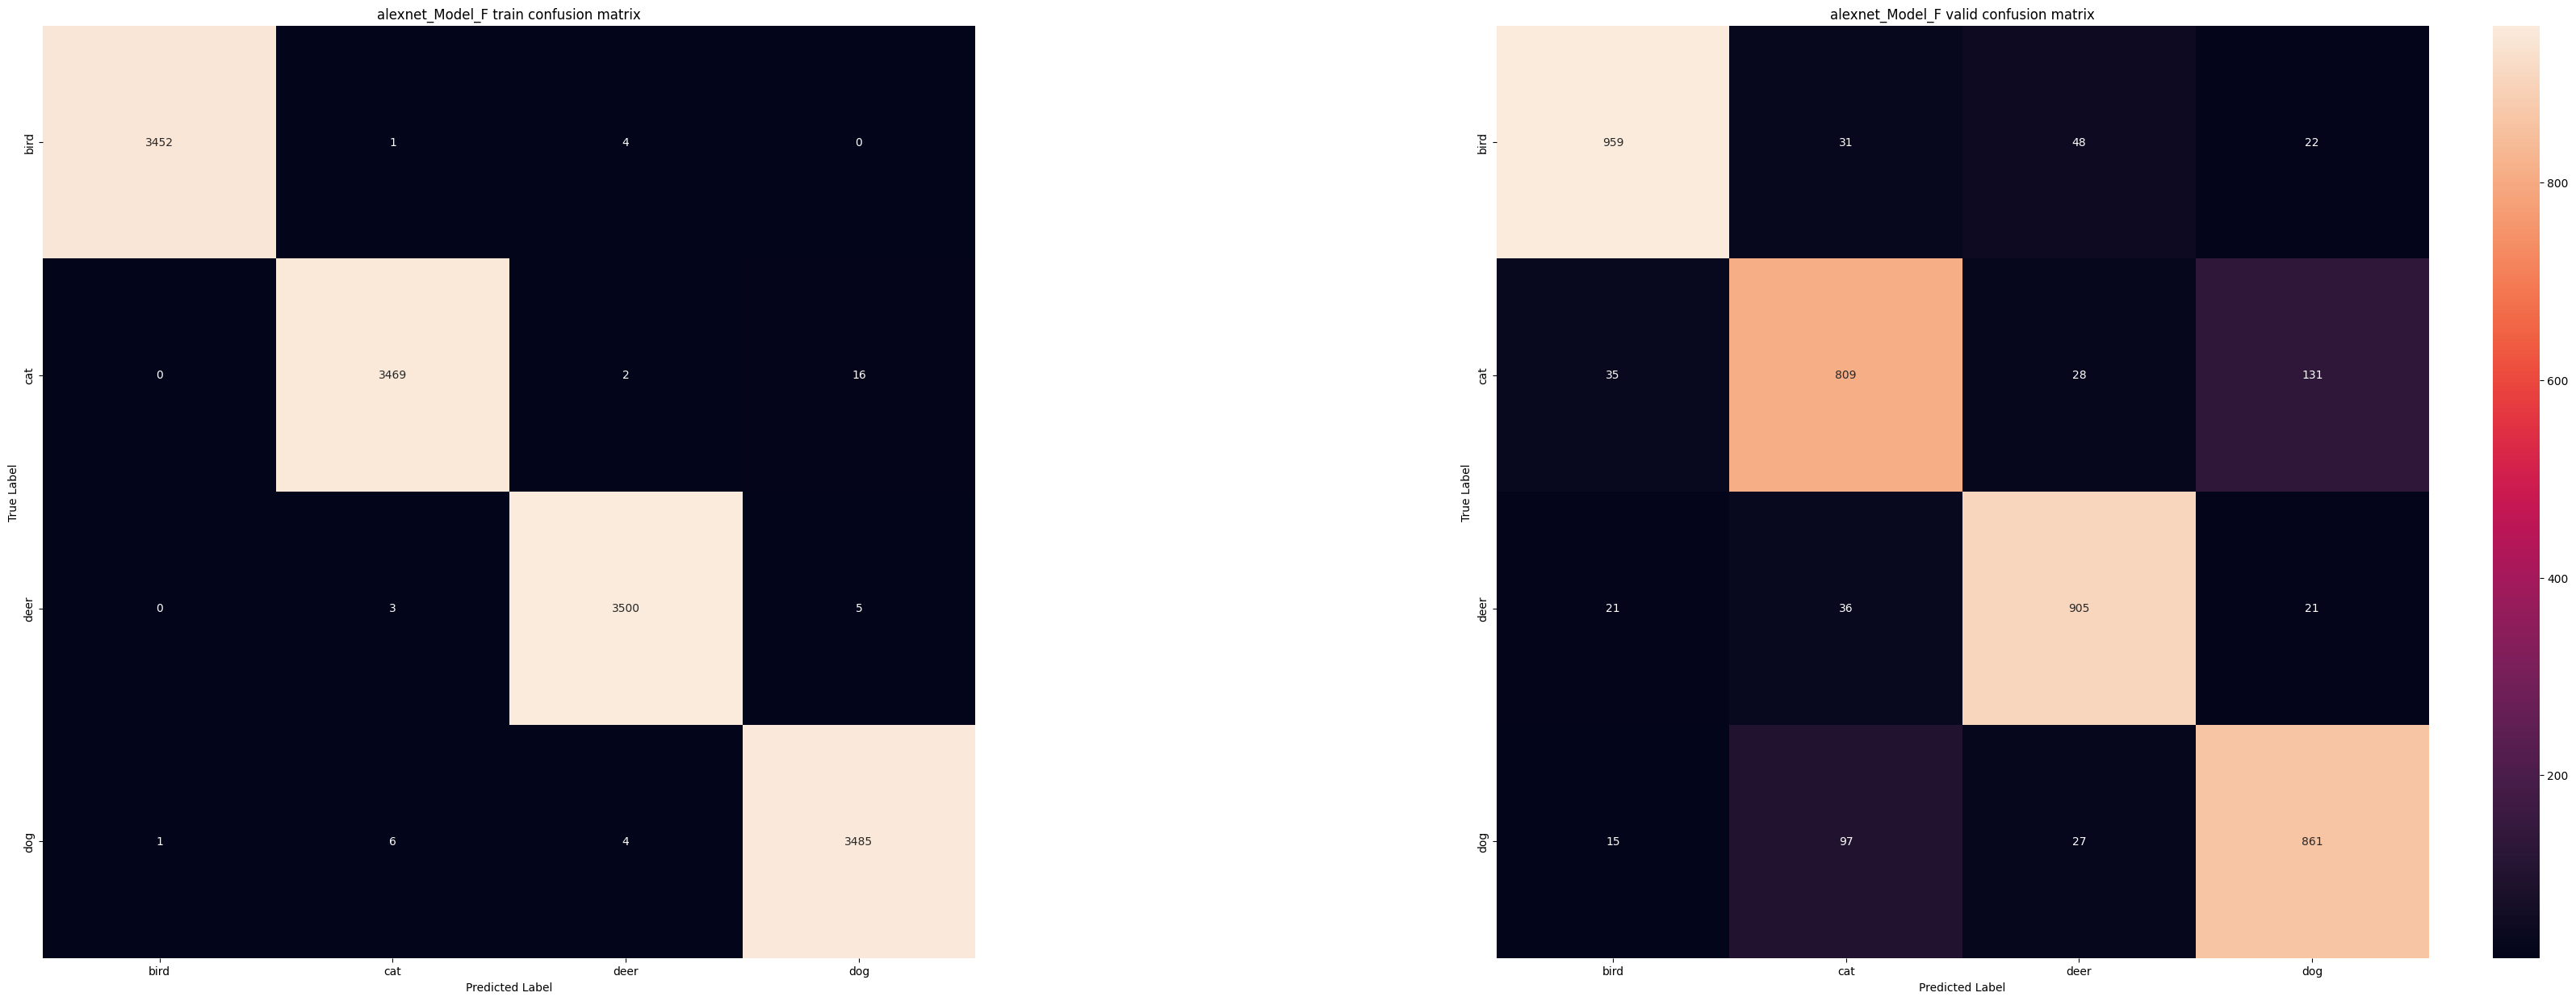

In [42]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [43]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [44]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,30959,0,2,0,0,0.931421,0.999834,0.999683,0.997004,False,True,True,True,True
1,4089,3,3,7,3,0.999081,0.563460,0.996260,0.999912,True,False,True,False,False
2,48874,8,2,8,8,0.999187,0.971412,0.999987,1.000000,False,True,True,True,True
3,2404,3,3,7,3,0.997355,0.979055,0.855005,0.998526,True,False,True,False,False
4,13482,7,4,7,7,0.956820,1.000000,0.998923,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,22449,0,2,0,0,0.973568,0.999924,0.998876,0.999777,False,True,True,True,True
34996,6708,9,3,9,9,0.987736,0.994726,0.999447,1.000000,False,True,True,True,True
34997,13003,9,3,9,9,0.857149,0.999925,0.999995,1.000000,False,True,True,True,True
34998,21474,1,4,1,1,0.828944,1.000000,1.000000,1.000000,False,True,True,True,True


In [45]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
110,45098,6,4,6,6,0.677907,0.981555,0.923316,0.567239,False,True,True,False,True
169,8194,6,2,6,6,0.927816,0.992769,0.912160,0.723303,False,True,True,False,True
414,15644,7,3,7,7,0.755675,0.999993,0.990039,0.534104,False,True,True,False,True
543,6359,2,2,8,2,0.998151,0.657175,0.801844,0.999911,True,False,True,True,False
788,12142,7,4,7,7,0.919467,0.992543,0.469155,0.645579,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34541,36645,6,2,6,6,0.997000,0.956079,0.889157,0.812003,False,True,True,False,True
34572,10756,2,2,7,2,0.998965,0.467247,0.992519,0.772448,True,False,True,True,False
34709,35362,2,2,0,2,0.999995,0.799318,0.995097,0.515069,True,False,True,True,False
34724,21979,6,4,6,6,0.627984,0.881874,0.931189,0.570203,False,True,True,False,True


In [46]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

7    88
6    72
2    64
0    30
3    21
4    18
5    12
9     2
8     2
1     1
Name: Target, dtype: int64

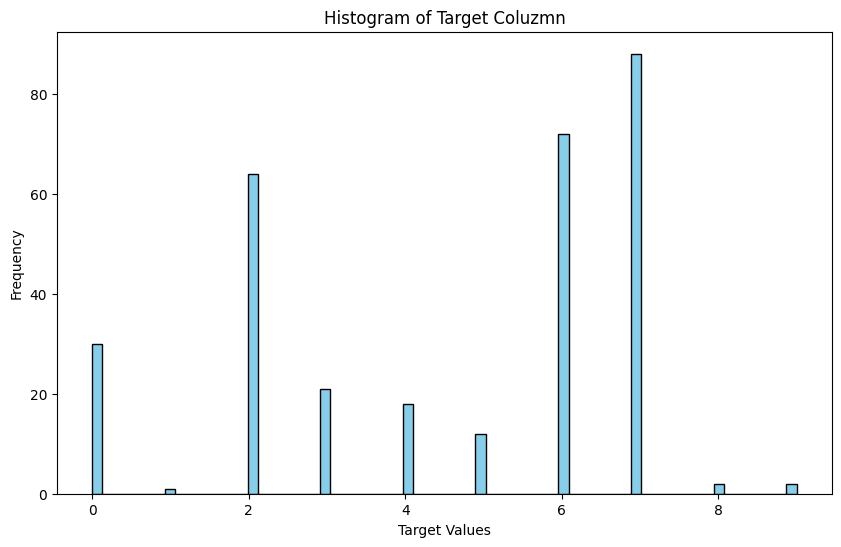

In [47]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [48]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,551,7,4,7,7,0.974772,1.000000,0.999957,0.999999,False,True,True,True,True
1,12785,0,4,0,0,0.937162,0.998810,0.999428,1.000000,False,True,True,True,True
2,10137,3,5,7,5,0.959950,0.985682,0.590207,0.999901,False,False,False,False,False
3,5026,2,2,6,2,1.000000,0.740733,0.999998,1.000000,True,False,True,False,False
4,12539,4,4,7,4,0.999866,0.998769,0.993324,0.998946,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,5095,6,3,8,3,0.997573,0.982011,0.668542,0.994222,False,False,False,True,True
9996,32425,5,5,7,5,1.000000,0.995121,1.000000,1.000000,True,False,True,False,False
9997,34428,7,3,7,3,0.820040,0.982516,0.920382,0.998947,False,True,False,False,True
9998,7720,6,3,6,6,0.997870,1.000000,0.999883,1.000000,False,True,True,True,True


In [49]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
23,24660,6,3,6,6,0.949561,0.866728,0.886038,0.644627,False,True,True,False,True
40,12759,7,4,7,4,0.963493,0.999997,0.989537,0.919072,False,True,False,False,True
59,25192,2,2,0,0,0.950352,0.986062,0.820219,0.946856,True,False,False,True,False
74,20993,6,4,7,4,0.997532,0.947900,0.568164,0.751584,False,False,False,False,True
102,37943,2,2,8,8,0.999401,0.781159,0.952750,0.999999,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9944,33134,2,2,0,2,0.999515,0.997413,0.511763,0.938444,True,False,True,True,False
9987,6641,7,4,7,7,0.891867,0.999975,0.607176,0.565790,False,True,True,False,True
9991,47559,7,5,7,7,0.588360,0.790220,0.748972,0.758460,False,True,True,False,True
9992,34735,2,2,0,1,0.541922,0.268316,0.480905,0.999979,True,False,False,True,False


In [50]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

7    124
6    108
2     82
3     56
0     48
4     43
5     14
8      6
1      5
9      2
Name: Target, dtype: int64

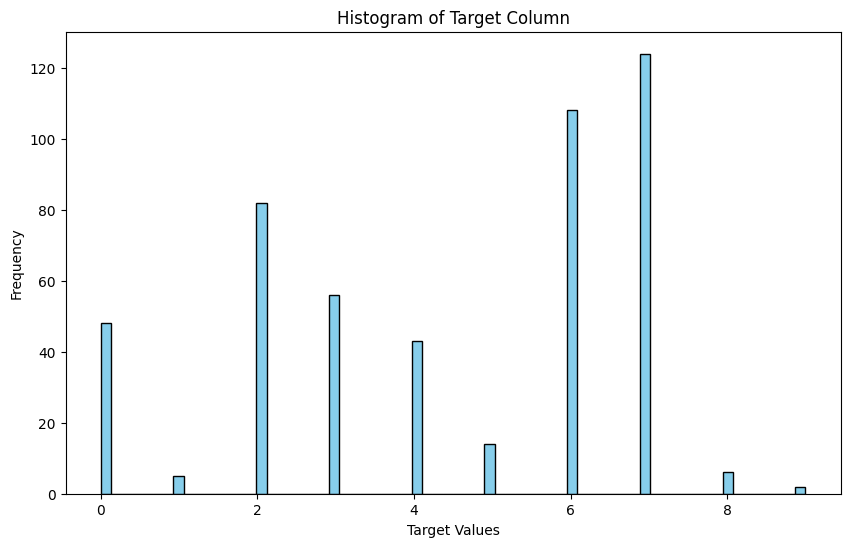

In [51]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()